# Merge CSVs on Common ID

In [1]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration pour afficher les graphiques dans le notebook
%matplotlib inline
plt.style.use('ggplot')
sns.set(style='whitegrid')

In [2]:
# Charger tous les fichiers CSV dans un dictionnaire de DataFrames
dataframes = {}

for csv_filename in ['Datasets/Tabular/Binary_pred/dataset1_with_target.csv', 'Datasets/Tabular/Binary_pred/dataset2_features_only.csv']:
    dataframes[csv_filename] = pd.read_csv(csv_filename)
    print(f"Table {csv_filename} shape: {dataframes[csv_filename].shape}")
    print(f"Column names: {dataframes[csv_filename].columns.tolist()}")

# Afficher la liste des DataFrames chargés
list(dataframes.keys())


Table Datasets/Tabular/Binary_pred/dataset1_with_target.csv shape: (10000, 13)
Column names: ['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9', 'Gender', 'Education_Level', 'YTarget', 'ID']
Table Datasets/Tabular/Binary_pred/dataset2_features_only.csv shape: (10000, 12)
Column names: ['Extra_Feature_1', 'Extra_Feature_2', 'Extra_Feature_3', 'Extra_Feature_4', 'Extra_Feature_5', 'Extra_Feature_6', 'Extra_Feature_7', 'Extra_Feature_8', 'Extra_Feature_9', 'Employment_Status', 'Marital_Status', 'ID']


['Datasets/Tabular/Binary_pred/dataset1_with_target.csv',
 'Datasets/Tabular/Binary_pred/dataset2_features_only.csv']

In [3]:
# Fusionner tous les DataFrames sur la colonne d'ID commune
merged_df = None

for df_name, df in dataframes.items():
    if "ID" not in df.columns:
        print(f"Attention: La colonne 'ID' n'est pas présente dans {df_name}")
        continue
        
    if merged_df is None:
        merged_df = df.copy()
    else:
        # Utiliser un suffixe pour éviter la duplication des noms de colonnes
        merged_df = pd.merge(merged_df, df, on="ID", how='outer', 
                            suffixes=('', f'_{df_name}'))
# Standardize merged df
df = merged_df

# Afficher des informations sur le DataFrame fusionné
print("Shape du DataFrame final:", df.shape)
print("Colonnes du DataFrame final:", df.columns.tolist())
df.head()


Shape du DataFrame final: (10000, 24)
Colonnes du DataFrame final: ['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9', 'Gender', 'Education_Level', 'YTarget', 'ID', 'Extra_Feature_1', 'Extra_Feature_2', 'Extra_Feature_3', 'Extra_Feature_4', 'Extra_Feature_5', 'Extra_Feature_6', 'Extra_Feature_7', 'Extra_Feature_8', 'Extra_Feature_9', 'Employment_Status', 'Marital_Status']


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Gender,...,Extra_Feature_2,Extra_Feature_3,Extra_Feature_4,Extra_Feature_5,Extra_Feature_6,Extra_Feature_7,Extra_Feature_8,Extra_Feature_9,Employment_Status,Marital_Status
0,2.723440,1.866519,1.113137,3.086300,1.139884,-0.198606,1.160009,-0.299338,-1.039989,M,...,-1.251460,-1.948419,0.994818,1.645155,0.534798,-0.455526,-3.209067,-0.513121,Employed,Divorced
1,2.473457,-0.932929,0.831094,3.663572,-0.503653,-0.417393,-0.490881,-0.812725,-2.089574,F,...,0.510845,-0.720984,-0.654982,-0.789022,-0.427658,-3.214260,-2.067535,0.196986,Employed,Married
2,1.433575,0.045074,1.819289,-1.042065,0.913403,-2.466178,-0.719618,0.547549,-2.032326,M,...,0.335552,0.443973,-0.095135,1.377356,-1.278258,-1.756094,1.106143,-0.466778,Employed,Single
3,1.786608,1.027379,1.628780,2.337084,-1.038550,0.803351,-0.140196,-0.802828,0.672490,M,...,-0.069857,0.135114,-1.560000,1.309448,0.176337,1.415758,-2.831500,-1.332835,Employed,Married
4,-2.543248,-0.111511,2.124107,1.570665,1.531572,0.502406,-1.533310,2.029766,-1.126915,F,...,0.122694,-0.822610,0.809790,-0.137280,0.185757,0.617563,0.404348,-0.783237,Employed,Married


In [4]:
# Transform categorical columns to numerical
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in df.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
df.head()


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Gender,...,Extra_Feature_2,Extra_Feature_3,Extra_Feature_4,Extra_Feature_5,Extra_Feature_6,Extra_Feature_7,Extra_Feature_8,Extra_Feature_9,Employment_Status,Marital_Status
0,2.723440,1.866519,1.113137,3.086300,1.139884,-0.198606,1.160009,-0.299338,-1.039989,1,...,-1.251460,-1.948419,0.994818,1.645155,0.534798,-0.455526,-3.209067,-0.513121,0,0
1,2.473457,-0.932929,0.831094,3.663572,-0.503653,-0.417393,-0.490881,-0.812725,-2.089574,0,...,0.510845,-0.720984,-0.654982,-0.789022,-0.427658,-3.214260,-2.067535,0.196986,0,1
2,1.433575,0.045074,1.819289,-1.042065,0.913403,-2.466178,-0.719618,0.547549,-2.032326,1,...,0.335552,0.443973,-0.095135,1.377356,-1.278258,-1.756094,1.106143,-0.466778,0,2
3,1.786608,1.027379,1.628780,2.337084,-1.038550,0.803351,-0.140196,-0.802828,0.672490,1,...,-0.069857,0.135114,-1.560000,1.309448,0.176337,1.415758,-2.831500,-1.332835,0,1
4,-2.543248,-0.111511,2.124107,1.570665,1.531572,0.502406,-1.533310,2.029766,-1.126915,0,...,0.122694,-0.822610,0.809790,-0.137280,0.185757,0.617563,0.404348,-0.783237,0,1


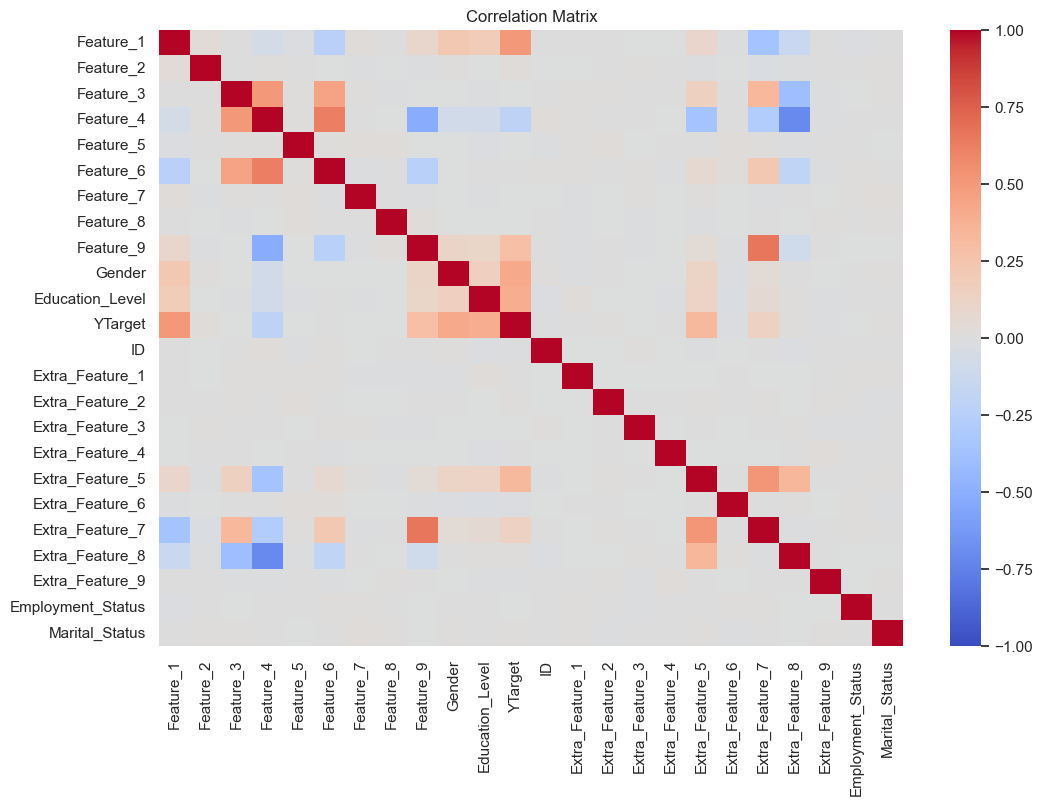

In [5]:
# Display correlation matrix
corr_matrix = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()


# Random Forest

In [6]:
import xgboost as xgb
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
target_column = "YTarget"
num_classes = 2

# Split the data
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=[target_column]), df[target_column], test_size=0.2, random_state=42)

# Scale features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create DMatrix for XGBoost
dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
dtest = xgb.DMatrix(X_test_scaled, label=y_test)

# Set parameters for XGBoost with better defaults
params = {
    'objective': 'multi:softmax',
    'num_class': num_classes,
    'max_depth': 6,
    'eta': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1,
    'eval_metric': 'mlogloss'
}

# Train the model with early stopping
num_rounds = 1000
eval_list = [(dtrain, 'train'), (dtest, 'eval')]
model = xgb.train(params, dtrain, num_rounds, eval_list,
               early_stopping_rounds=20, verbose_eval=100)


[0]	train-mlogloss:0.61717	eval-mlogloss:0.61808


/Users/eliottvalette/Library/Mobile Documents/com~apple~CloudDocs/Documents/Codage /NoteBook Maker/.venv/lib/python3.10/site-packages/xgboost/core.py:726: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[100]	train-mlogloss:0.02805	eval-mlogloss:0.06929


[182]	train-mlogloss:0.00792	eval-mlogloss:0.06287


Accuracy: 0.9830

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1006
           1       0.99      0.97      0.98       994

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



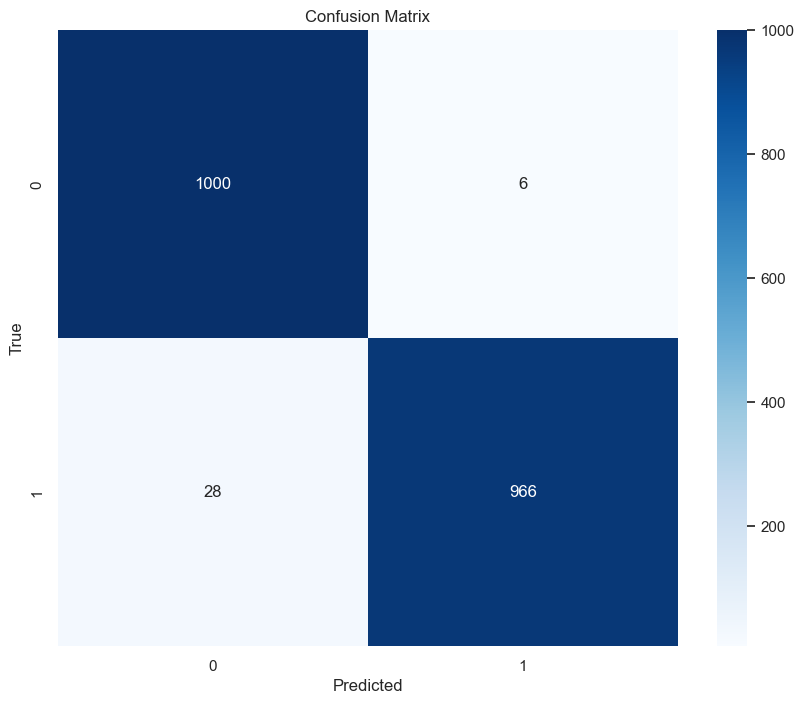

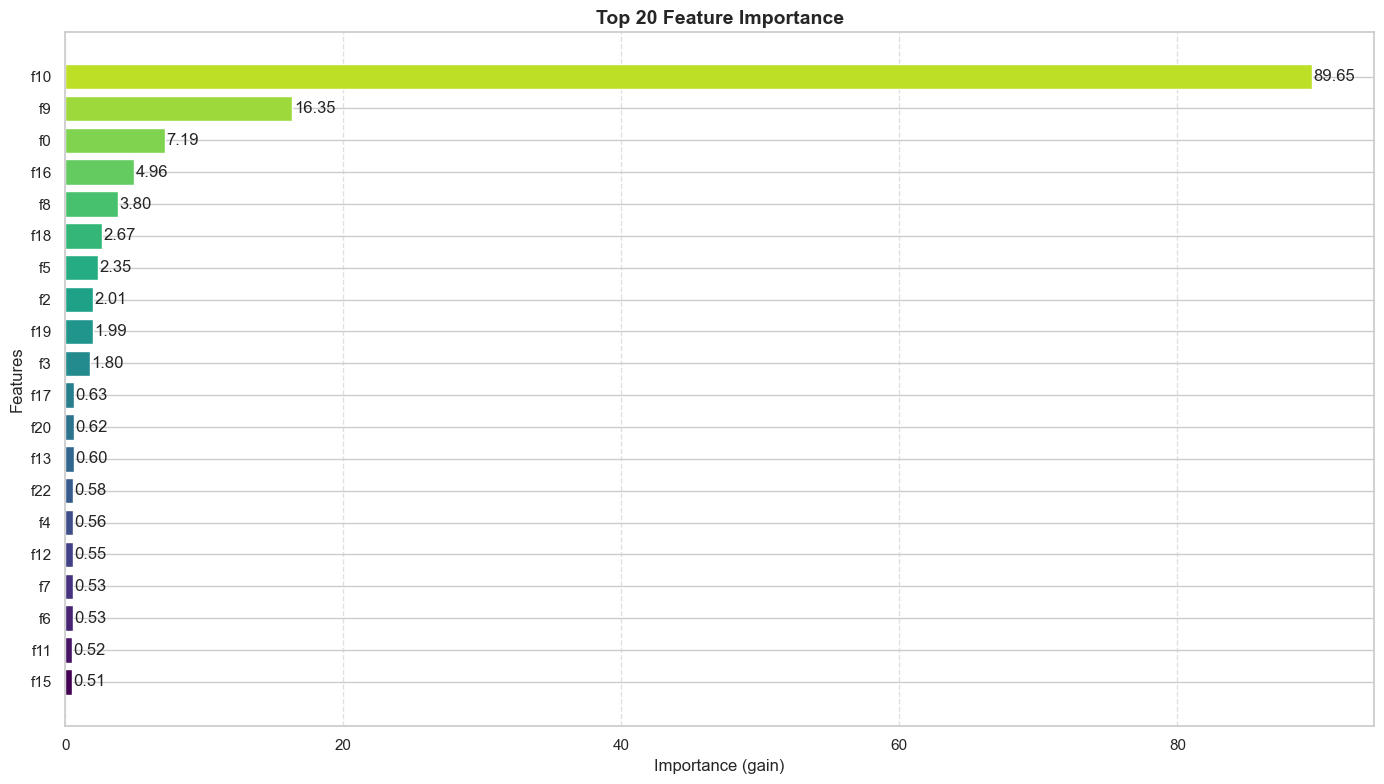

In [8]:
# Make predictions
y_pred = model.predict(dtest)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Feature importance with better visualization
plt.figure(figsize=(14, 8))

# Get feature importance
importance = model.get_score(importance_type='gain')
features = list(importance.keys())
scores = list(importance.values())

# Sort by importance
indices = np.argsort(scores)[-20:]  # Top 20 features

# Create colorful horizontal bar chart
colors = plt.cm.viridis(np.linspace(0, 0.9, len(indices)))
plt.barh(range(len(indices)), [scores[i] for i in indices], color=colors)
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importance (gain)')
plt.ylabel('Features')
plt.title(f'Top {min(20, len(features))} Feature Importance', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Add values on bars
for i, v in enumerate([scores[idx] for idx in indices]):
    plt.text(v + 0.1, i, f"{v:.2f}", va='center')

plt.tight_layout()
plt.show()
